In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("indian_diseases_dataset.csv")
df.head()

,patient_id,age,age_group,gender,state,city,region,urban_rural,disease_name,disease_category,severity,diagnosis_date,year,month,season,symptoms,comorbidity,smoking_status,alcohol_use,bmi,blood_group,income_level,insurance_status,treatment_type,hospital_type,days_hospitalized,treatment_cost_inr,outcome,death_flag,cause_of_death,recovery_days,follow_up_required
0,IND-00000001,70,70-79,Female,Bihar,Patna,East,Semi-Urban,Diarrhea,Waterborne,Severe,2018-01-01,2018,January,Winter,"Vomiting, Abdominal pain, Fever",NaN,Never,NaN,20.1,A+,Middle,Employer,Medication,Government,21,102.0,Recovering,0,NaN,42.0,Yes
1,IND-00000002,27,20-29,Other,Gujarat,Surat,West,Urban,Chikungunya,Vector-Borne,Mild,2018-01-01,2018,January,Winter,"Vomiting, Rash, Joint pain, Nausea, Severe Hea...",Kidney Disease,Never,Regular,18.3,O+,High,Uninsured,Medication,Government,0,1151.0,Recovered,0,NaN,18.0,Yes
2,IND-00000003,66,60-69,Other,Jharkhand,Bokaro,East,Rural,Hypertension,Non-Communicable,Mild,2018-01-01,2018,January,Winter,"Dizziness, Chest pain, Swelling, Shortness of ...",Heart Disease,Never,NaN,25.3,B+,Below Poverty Line,Private,Medication,Government,2,89.0,Chronic Management,0,NaN,NaN,Yes
3,IND-00000004,27,20-29,Female,Karnataka,Hubli,South,Rural,Tuberculosis,Infectious,Severe,2018-01-01,2018,January,Winter,"Fever, Body ache, Nausea, Fatigue, Chills",NaN,Never,Occasional,19.5,O-,Lower,Private,Surgery,Government,9,1269.0,Recovering,0,NaN,69.0,Yes
4,IND-00000005,40,40-49,Male,Karnataka,Belagavi,South,Rural,Chronic Kidney Disease,Non-Communicable,Critical,2018-01-01,2018,January,Winter,"Blurred vision, Dizziness, Unexplained weight ...",Kidney Disease,Former,Regular,29.3,A+,Middle,Ayushman Bharat,Palliative,Private,31,670576.0,Deceased,1,Complications from Chronic Kidney Disease,NaN,No


In [4]:
print(df.shape)

(20000, 32)


In [5]:
df.columns

Index(['patient_id', 'age', 'age_group', 'gender', 'state', 'city', 'region',
       'urban_rural', 'disease_name', 'disease_category', 'severity',
       'diagnosis_date', 'year', 'month', 'season', 'symptoms', 'comorbidity',
       'smoking_status', 'alcohol_use', 'bmi', 'blood_group', 'income_level',
       'insurance_status', 'treatment_type', 'hospital_type',
       'days_hospitalized', 'treatment_cost_inr', 'outcome', 'death_flag',
       'cause_of_death', 'recovery_days', 'follow_up_required'],
      dtype='object')

In [6]:
df.isnull().sum()

patient_id                0
age                       0
age_group                 0
gender                    0
state                     0
city                      0
region                    0
urban_rural               0
disease_name              0
disease_category          0
severity                  0
diagnosis_date            0
year                      0
month                     0
season                    0
symptoms                  0
comorbidity            6599
smoking_status            0
alcohol_use            6627
bmi                       0
blood_group               0
income_level              0
insurance_status          0
treatment_type            0
hospital_type             0
days_hospitalized         0
treatment_cost_inr        0
outcome                   0
death_flag                0
cause_of_death        18178
recovery_days          6307
follow_up_required        0
dtype: int64

In [7]:
clean_df = df.copy()

In [8]:
clean_df["cause_of_death"] = clean_df["cause_of_death"].fillna("Not Applicable")

In [9]:
clean_df["comorbidity"] = clean_df["comorbidity"].fillna("None")

In [10]:
clean_df["alcohol_use"] = clean_df["alcohol_use"].fillna("Unknown")

In [11]:
clean_df.groupby("outcome")["recovery_days"].count()

outcome
Chronic Management       0
Deceased                 0
Recovered             8440
Recovering            5253
Name: recovery_days, dtype: int64

In [12]:
clean_df.isnull().sum()

patient_id               0
age                      0
age_group                0
gender                   0
state                    0
city                     0
region                   0
urban_rural              0
disease_name             0
disease_category         0
severity                 0
diagnosis_date           0
year                     0
month                    0
season                   0
symptoms                 0
comorbidity              0
smoking_status           0
alcohol_use              0
bmi                      0
blood_group              0
income_level             0
insurance_status         0
treatment_type           0
hospital_type            0
days_hospitalized        0
treatment_cost_inr       0
outcome                  0
death_flag               0
cause_of_death           0
recovery_days         6307
follow_up_required       0
dtype: int64

In [13]:
clean_df.duplicated().sum()

np.int64(0)

In [14]:
clean_df["diagnosis_date"] = pd.to_datetime(clean_df["diagnosis_date"])

In [15]:
clean_df.to_csv("clean_patient_data.csv", index=False)

In [16]:
clean_df["disease_name"].value_counts()

disease_name
Leptospirosis             664
Asthma                    660
Hypertension              654
Gastroenteritis           654
Malaria                   652
Oral Cancer               652
Kala-Azar                 649
Jaundice (Hepatitis A)    639
Diarrhea                  636
Chikungunya               635
Depression                634
Pneumonia                 631
Hepatitis B               631
Anxiety Disorder          631
Chronic Kidney Disease    630
COPD                      627
Thalassemia               626
Japanese Encephalitis     625
HIV/AIDS                  623
Breast Cancer             619
Diabetes (Type 2)         619
Dengue                    618
Filariasis                615
Stroke                    609
Sickle Cell Anemia        606
Swine Flu (H1N1)          603
Cholera                   601
Tuberculosis              596
Heart Disease             594
Lung Cancer               593
COVID-19                  591
Typhoid                   583
Name: count, dtype: int64

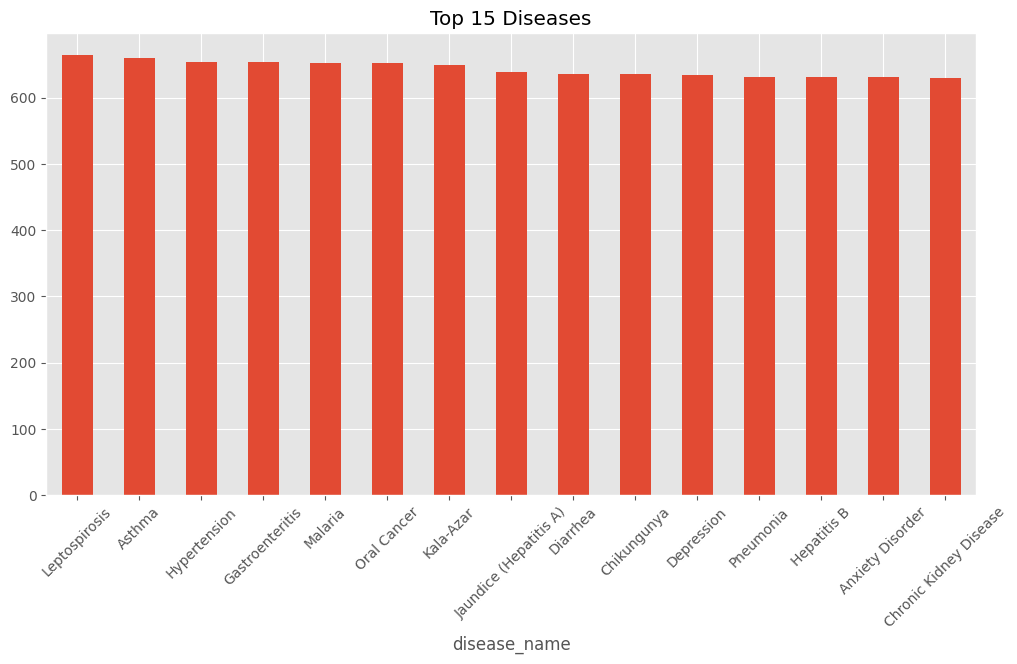

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
clean_df["disease_name"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Diseases")
plt.xticks(rotation=45)
plt.show()

In [18]:
clean_df["disease_category"].value_counts()

disease_category
Non-Communicable    4970
Vector-Borne        3794
Respiratory         3112
Infectious          3097
Waterborne          2530
Mental Health       1265
Genetic             1232
Name: count, dtype: int64

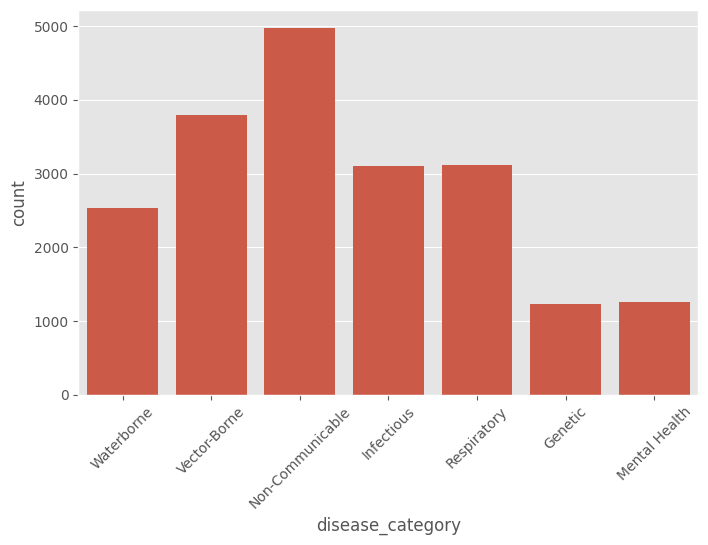

In [19]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=clean_df, x="disease_category")
plt.xticks(rotation=45)
plt.show()

In [20]:
clean_df["severity"].value_counts()

severity
Moderate    6516
Severe      6305
Mild        4850
Critical    2329
Name: count, dtype: int64

In [21]:
clean_df["gender"].value_counts()

gender
Male      9926
Female    9873
Other      201
Name: count, dtype: int64

In [22]:
state_cases = clean_df["state"].value_counts()

state_cases.head(15)

state
Uttar Pradesh     2742
Bihar             1715
Maharashtra       1705
Madhya Pradesh    1416
West Bengal       1342
Tamil Nadu        1209
Rajasthan         1174
Gujarat           1047
Karnataka         1025
Andhra Pradesh     893
Odisha             699
Telangana          639
Assam              539
Kerala             503
Haryana            501
Name: count, dtype: int64

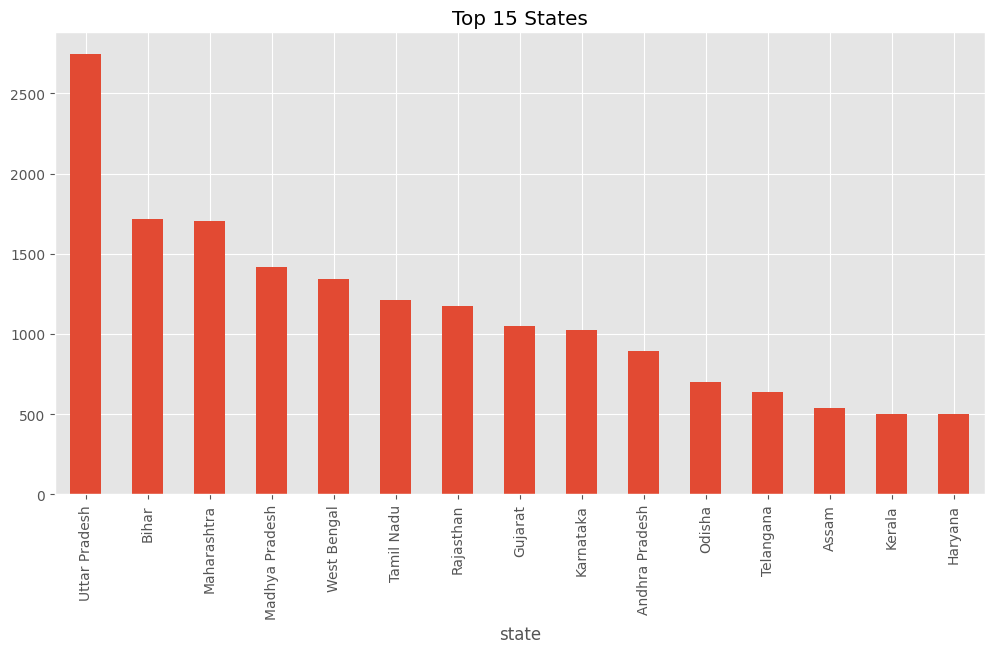

In [23]:
plt.figure(figsize=(12,6))
state_cases.head(15).plot(kind="bar")
plt.title("Top 15 States")
plt.show()

In [24]:
monthly_cases = clean_df.groupby(["year", "month"]).size().reset_index(name="cases")

monthly_cases.head()

,year,month,cases
0,2018,April,184
1,2018,August,264
2,2018,December,233
3,2018,February,218
4,2018,January,241


In [25]:
clean_df["treatment_type"].value_counts()

treatment_type
Medication          13073
Surgery              3138
ICU + Ventilator     1433
Home Remedies         953
Therapy               666
Observation           506
Palliative            231
Name: count, dtype: int64

In [26]:
clean_df["hospital_type"].value_counts()

hospital_type
Government                  7083
Private                     6963
Primary Health Center       3026
Community Health Center     1992
AIIMS / Apex Institution     936
Name: count, dtype: int64

In [27]:
clean_df["outcome"].value_counts()

outcome
Recovered             8440
Recovering            5253
Chronic Management    4485
Deceased              1822
Name: count, dtype: int64

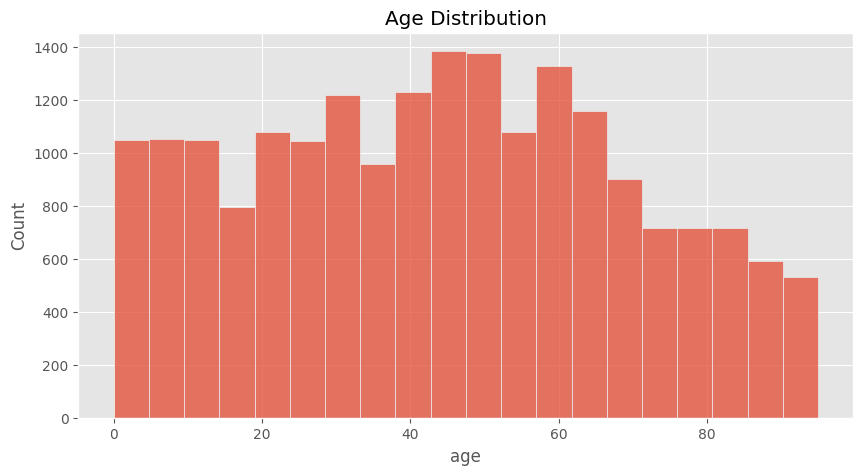

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(clean_df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

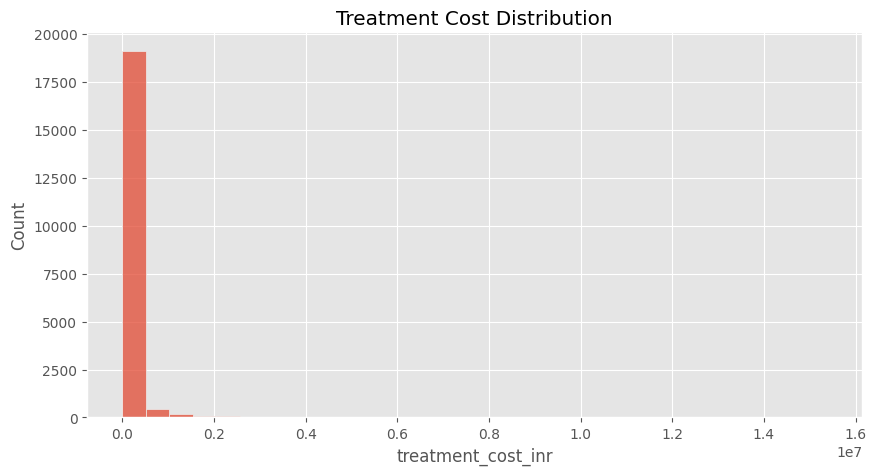

In [29]:
plt.figure(figsize=(10,5))
sns.histplot(clean_df["treatment_cost_inr"], bins=30)
plt.title("Treatment Cost Distribution")
plt.show()

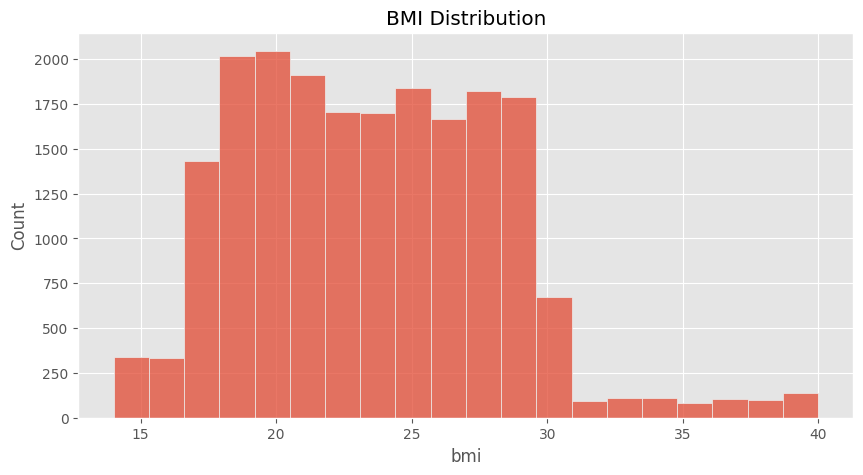

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(clean_df["bmi"], bins=20)
plt.title("BMI Distribution")
plt.show()

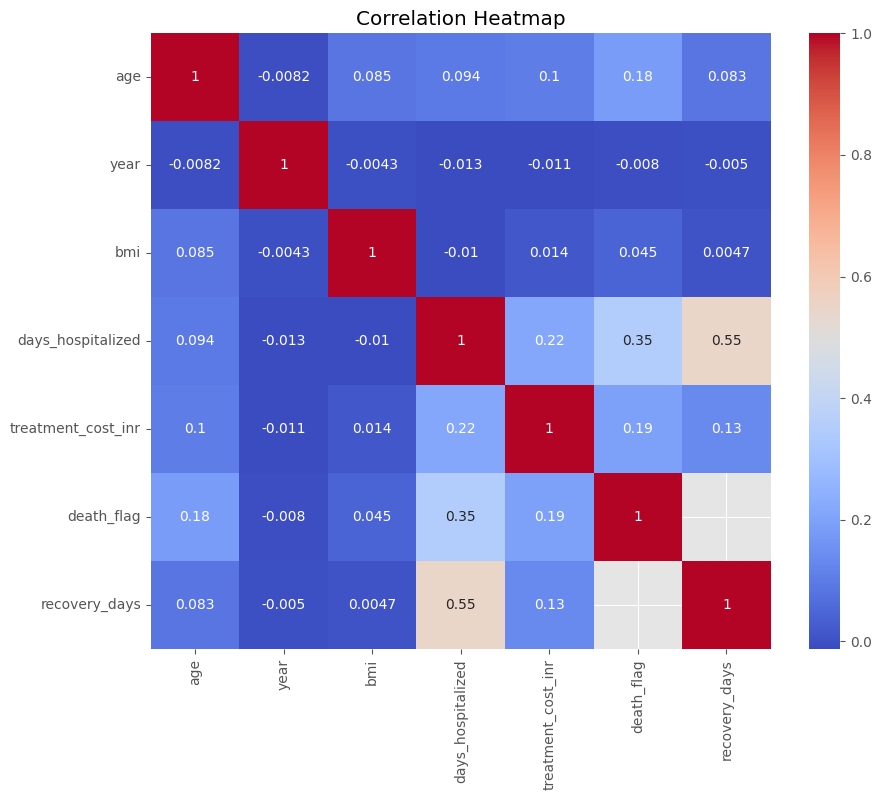

In [31]:
numeric_df = clean_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [32]:
clean_df.dtypes

patient_id                    object
age                            int64
age_group                     object
gender                        object
state                         object
city                          object
region                        object
urban_rural                   object
disease_name                  object
disease_category              object
severity                      object
diagnosis_date        datetime64[ns]
year                           int64
month                         object
season                        object
symptoms                      object
comorbidity                   object
smoking_status                object
alcohol_use                   object
bmi                          float64
blood_group                   object
income_level                  object
insurance_status              object
treatment_type                object
hospital_type                 object
days_hospitalized              int64
treatment_cost_inr           float64
o

In [33]:
month_map = {
    "January":1,
    "February":2,
    "March":3,
    "April":4,
    "May":5,
    "June":6,
    "July":7,
    "August":8,
    "September":9,
    "October":10,
    "November":11,
    "December":12
}

clean_df["month"] = clean_df["month"].map(month_map)

In [34]:
clean_df[["month"]].head(10)

,month
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [35]:
forecast_df = (
    clean_df.groupby(
        [
            "year",
            "month",
            "state",
            "disease_name"
        ]
    )
    .size()
    .reset_index(name="total_cases")
)

forecast_df.to_csv("forecast_dataset.csv", index=False)

In [37]:
forecast_df.head()

,year,month,state,disease_name,total_cases
0,2018,1,Andhra Pradesh,Anxiety Disorder,2
1,2018,1,Andhra Pradesh,Asthma,1
2,2018,1,Andhra Pradesh,COVID-19,1
3,2018,1,Andhra Pradesh,Depression,1
4,2018,1,Andhra Pradesh,Diabetes (Type 2),1


In [38]:
print(forecast_df.shape)

(15853, 5)


In [40]:
clean_df.to_csv(
    "clean_patient_data1.csv",
    index=False
)

forecast_df.to_csv(
    "forecast_df.csv",
    index=False
)